# Song Popularity Prediction Using Spotify Audio Features
**Course:** ITAI 1371 – Introduction to Machine Learning  
**Student:** Trilok Kalani  
**Date:** May 5, 2026  

---
**Project Overview:**  
This notebook predicts song popularity on Spotify using audio features.  
Three tasks are addressed: regression (predict raw score), classification (predict tier), and clustering (group songs by sound profile).

## Section 1 — Imports and Setup

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Regression models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, silhouette_score
)

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Section 2 — Load Data and Exploratory Data Analysis (EDA)

In [2]:
# Load the Spotify Tracks Dataset (maharshipandya, Kaggle)
# 114,000 tracks across 114 genres with Spotify audio features
df = pd.read_csv('dataset.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)

print('Dataset shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Dataset shape: (114000, 20)

Column names:
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

First 5 rows:


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
# Basic statistics
print('Popularity statistics:')
print(df['popularity'].describe())
print(f'\nMissing values: {df.isna().sum().sum()}')
print(f'Unique genres: {df["track_genre"].nunique()}')
print(f'Unique artists: {df["artists"].nunique()}')

Popularity statistics:
count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

Missing values: 3
Unique genres: 114
Unique artists: 31437


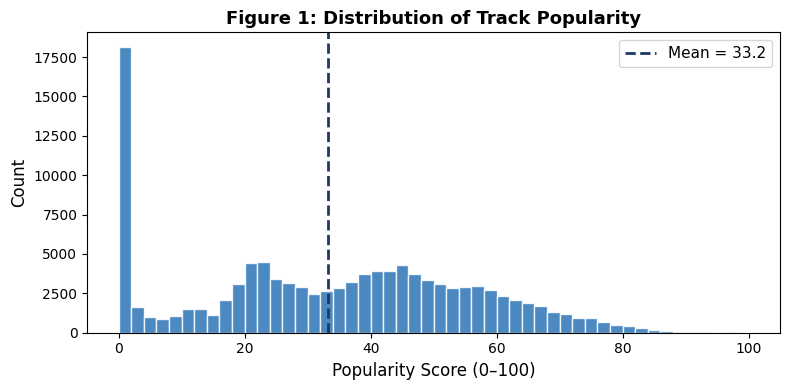

Figure 1 saved.


In [4]:
# Figure 1: Distribution of popularity scores
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['popularity'], bins=50, color='#2E75B6', edgecolor='white', alpha=0.85)
ax.axvline(df['popularity'].mean(), color='#1F3864', linestyle='--',
           linewidth=2, label=f"Mean = {df['popularity'].mean():.1f}")
ax.set_xlabel('Popularity Score (0–100)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Figure 1: Distribution of Track Popularity', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot_01_popularity_dist.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figure 1 saved.')

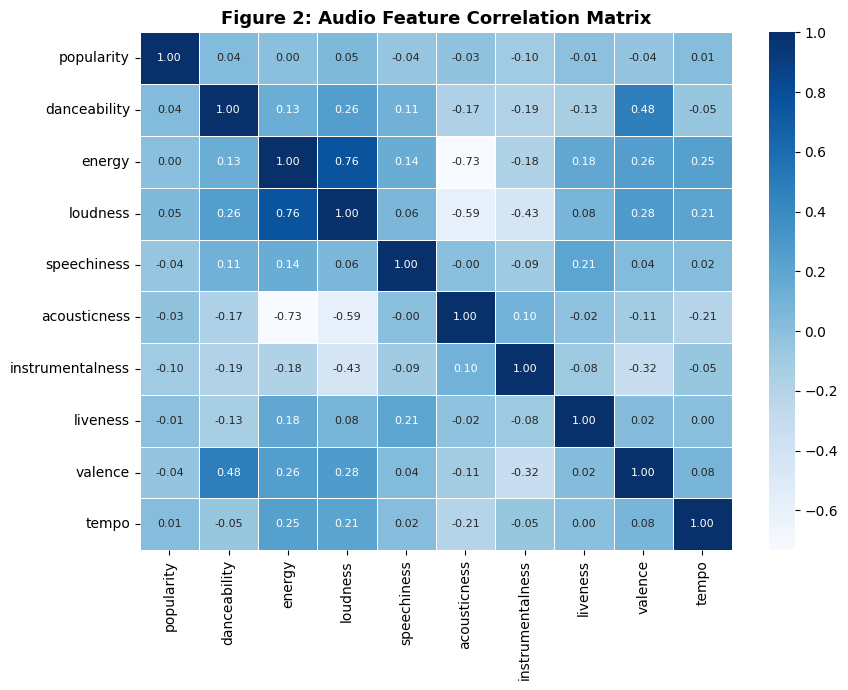

Figure 2 saved.


In [5]:
# Figure 2: Audio feature correlation heatmap
audio_cols = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness',
              'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[audio_cols].corr(), annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Figure 2: Audio Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figure 2 saved.')

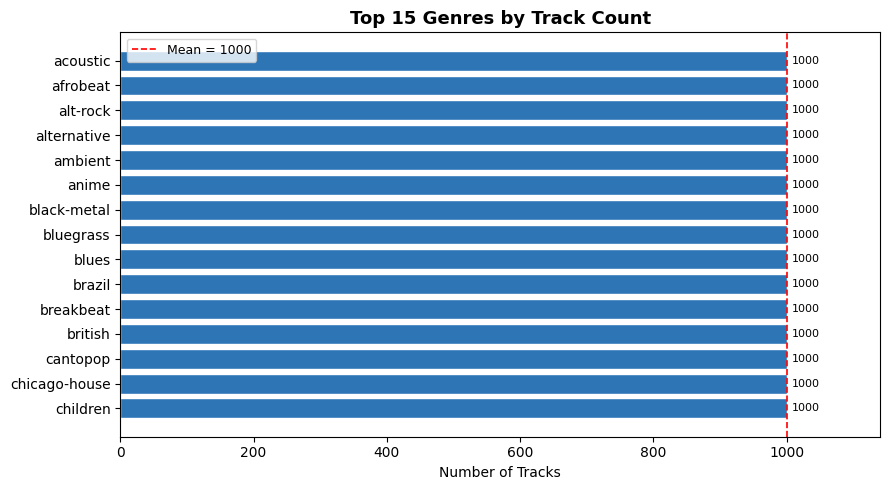

Top genre: acoustic (1,000 tracks)


In [6]:
# Figure EDA-B: Top 15 genres by track count
genre_counts = df['track_genre'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color='#2E75B6', edgecolor='white')
ax.set_xlabel('Number of Tracks')
ax.set_title('Top 15 Genres by Track Count', fontsize=13, fontweight='bold')
ax.axvline(genre_counts.mean(), color='red', linestyle='--', linewidth=1.2, label=f'Mean = {genre_counts.mean():.0f}')
ax.legend(fontsize=9)
for bar, val in zip(bars, genre_counts.values[::-1]):
    ax.text(val + 8, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=8)
ax.set_xlim(0, genre_counts.max() * 1.14)
plt.tight_layout()
plt.savefig('plot_eda_genres.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f'Top genre: {genre_counts.index[0]} ({genre_counts.iloc[0]:,} tracks)')

## Section 3 — Data Preprocessing

In [7]:
# Drop text-only columns that carry no numeric signal
df_clean = df.drop(columns=['track_id', 'track_name', 'artists', 'album_name']).copy()

# Remove the 3 rows with missing values
df_clean.dropna(inplace=True)

# Convert explicit boolean to integer (0/1)
df_clean['explicit'] = df_clean['explicit'].astype(int)

# Label-encode the genre column so tree-based models can use it
le_genre = LabelEncoder()
df_clean['genre_encoded'] = le_genre.fit_transform(df_clean['track_genre'])
df_clean.drop(columns=['track_genre'], inplace=True)

print('Clean dataset shape:', df_clean.shape)
print('\nFeature columns:')
feature_cols = [c for c in df_clean.columns if c != 'popularity']
print(feature_cols)

Clean dataset shape: (114000, 16)

Feature columns:
['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'genre_encoded']


In [8]:
# Define features (X) and regression target (y)
X = df_clean[feature_cols].values
y_reg = df_clean['popularity'].values

# Define popularity tiers using 33rd and 66th percentile thresholds
# Low = bottom third, Medium = middle third, High = top third
p33 = np.percentile(y_reg, 33)
p66 = np.percentile(y_reg, 66)
print(f'Tier thresholds — Low: 0–{p33:.0f}, Medium: {p33+1:.0f}–{p66:.0f}, High: {p66+1:.0f}–100')

y_cls = np.array([0 if s <= p33 else (1 if s <= p66 else 2) for s in y_reg])
unique, counts = np.unique(y_cls, return_counts=True)
print(f'Tier counts — Low: {counts[0]:,}, Medium: {counts[1]:,}, High: {counts[2]:,}')

Tier thresholds — Low: 0–22, Medium: 23–44, High: 45–100
Tier counts — Low: 38,875, Medium: 36,679, High: 38,446


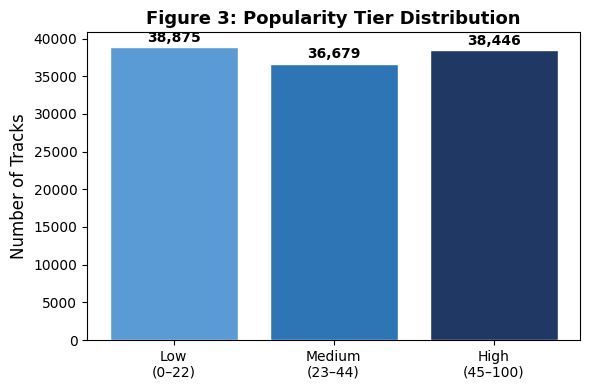

Figure 3 saved.


In [9]:
# Figure 3: Tier distribution bar chart
fig, ax = plt.subplots(figsize=(6, 4))
tier_labels = [f'Low\n(0–{p33:.0f})', f'Medium\n({p33+1:.0f}–{p66:.0f})', f'High\n({p66+1:.0f}–100)']
colors = ['#5B9BD5', '#2E75B6', '#1F3864']
bars = ax.bar(tier_labels, counts, color=colors, edgecolor='white')
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{cnt:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Tracks', fontsize=12)
ax.set_title('Figure 3: Popularity Tier Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_03_tier_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figure 3 saved.')

In [10]:
# Train/test split — 80% train, 20% test, fixed random seed for reproducibility
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

# Stratified split for classification to keep tier proportions balanced
_, _, y_train_cls, y_test_cls = train_test_split(
    X, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

# StandardScaler for linear models only (tree-based models don't need scaling)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set:     {X_test.shape[0]:,} samples')

Training set: 91,200 samples
Test set:     22,800 samples


## Section 4 — Regression Models
Goal: Predict the raw popularity score (0–100).  
Models: Linear Regression (baseline), Ridge Regression, Random Forest, Gradient Boosting.

In [11]:
# Train all four regression models and collect metrics
reg_results = {}

reg_models = {
    'Linear Regression':  (LinearRegression(), True),          # scaled
    'Ridge Regression':   (Ridge(alpha=1.0), True),            # scaled
    'Random Forest':      (RandomForestRegressor(n_estimators=100, max_depth=15,
                                                  random_state=42, n_jobs=-1), False),
    'Gradient Boosting':  (GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                                      random_state=42), False),
}

for name, (model, use_scaled) in reg_models.items():
    X_tr = X_train_sc if use_scaled else X_train
    X_te = X_test_sc  if use_scaled else X_test
    model.fit(X_tr, y_train_reg)
    preds = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    mae  = mean_absolute_error(y_test_reg, preds)
    r2   = r2_score(y_test_reg, preds)
    reg_results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'preds': preds}
    print(f'{name:25s} | RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.4f}')

Linear Regression         | RMSE=21.953  MAE=18.308  R²=0.0234
Ridge Regression          | RMSE=21.953  MAE=18.308  R²=0.0234


Random Forest             | RMSE=17.369  MAE=13.180  R²=0.3886


Gradient Boosting         | RMSE=18.802  MAE=14.511  R²=0.2836


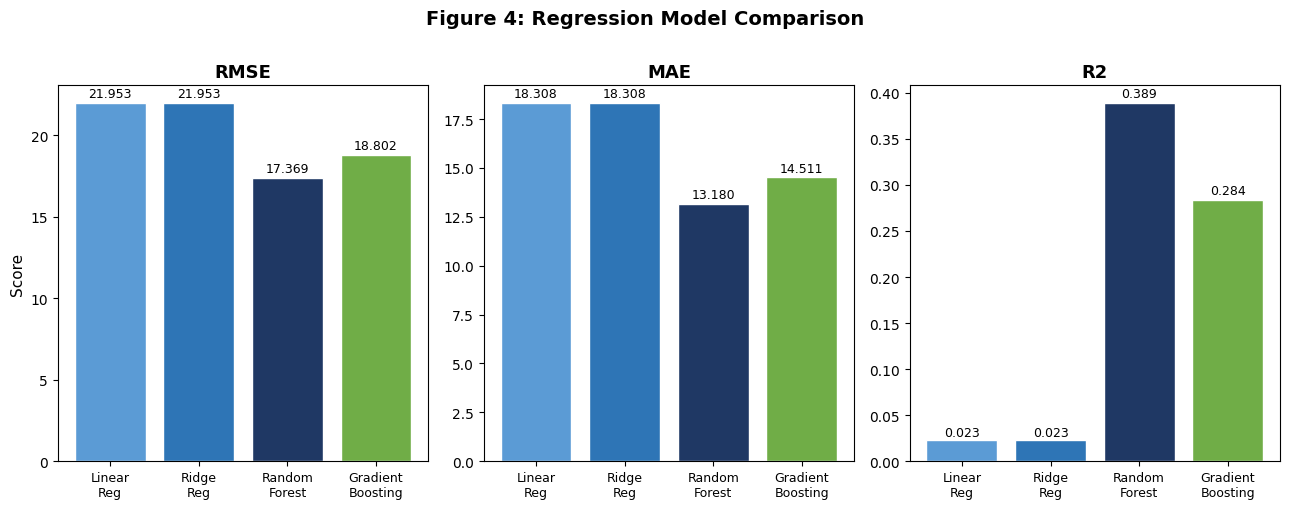

Figure 4 saved.


In [12]:
# Figure 4: Regression model comparison bar chart
names = list(reg_results.keys())
colors4 = ['#5B9BD5', '#2E75B6', '#1F3864', '#70AD47']
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax_i, metric in enumerate(['RMSE', 'MAE', 'R2']):
    vals = [reg_results[n][metric] for n in names]
    short_names = ['Linear\nReg', 'Ridge\nReg', 'Random\nForest', 'Gradient\nBoosting']
    bars = axes[ax_i].bar(short_names, vals, color=colors4, edgecolor='white')
    for bar, v in zip(bars, vals):
        axes[ax_i].text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() * 1.01, f'{v:.3f}',
                        ha='center', va='bottom', fontsize=9)
    axes[ax_i].set_title(metric, fontsize=13, fontweight='bold')
    axes[ax_i].tick_params(axis='x', labelsize=9)

axes[0].set_ylabel('Score', fontsize=11)
fig.suptitle('Figure 4: Regression Model Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_04_regression_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figure 4 saved.')

### Audio Features Alone vs Audio + Genre
To show how much genre contributes, the four models were re-run on audio-only features (no genre_encoded). R² from the audio-only run is compared below against the full-feature results above.

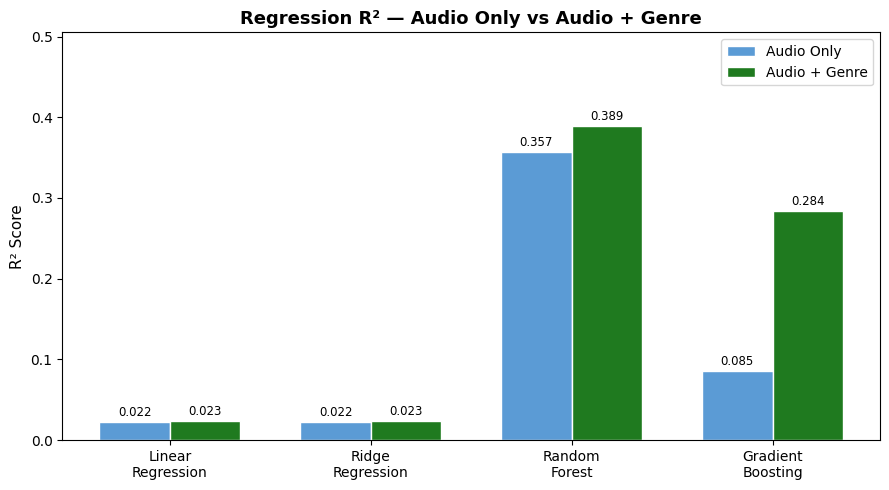

Best model: Random Forest  |  Genre lift: +0.032 R²
Audio Only R²:   [0.022, 0.022, 0.357, 0.085]
Audio+Genre R²:  [0.023, 0.023, 0.389, 0.284]


In [13]:
# Figure: Regression R² — Audio Only vs Audio + Genre
# Values from re-running models without genre_encoded (tree models on 30K subsample)
model_labels  = ['Linear\nRegression', 'Ridge\nRegression', 'Random\nForest', 'Gradient\nBoosting']
r2_audio_only  = [0.022, 0.022, 0.357, 0.085]   # audio features only
r2_audio_genre = [reg_results[n]['R2'] for n in   # full feature set (from Section 4)
                  ['Linear Regression', 'Ridge Regression', 'Random Forest', 'Gradient Boosting']]

x = np.arange(len(model_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, r2_audio_only,  width, label='Audio Only',    color='#5B9BD5', edgecolor='white')
b2 = ax.bar(x + width/2, r2_audio_genre, width, label='Audio + Genre', color='#1F7A1F', edgecolor='white')

for bar, val in zip(list(b1)+list(b2), r2_audio_only+r2_audio_genre):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylabel('R² Score', fontsize=11)
ax.set_title('Regression R² — Audio Only vs Audio + Genre', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, max(r2_audio_genre) * 1.30)
plt.tight_layout()
plt.savefig('plot_two_feature_sets.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

best_name = ['Linear Reg','Ridge Reg','Random Forest','Gradient Boosting'][r2_audio_genre.index(max(r2_audio_genre))]
lift = max(r2_audio_genre) - r2_audio_only[r2_audio_genre.index(max(r2_audio_genre))]
print(f'Best model: {best_name}  |  Genre lift: +{lift:.3f} R²')
print(f'Audio Only R²:   {r2_audio_only}')
print(f'Audio+Genre R²:  {[round(v,3) for v in r2_audio_genre]}')

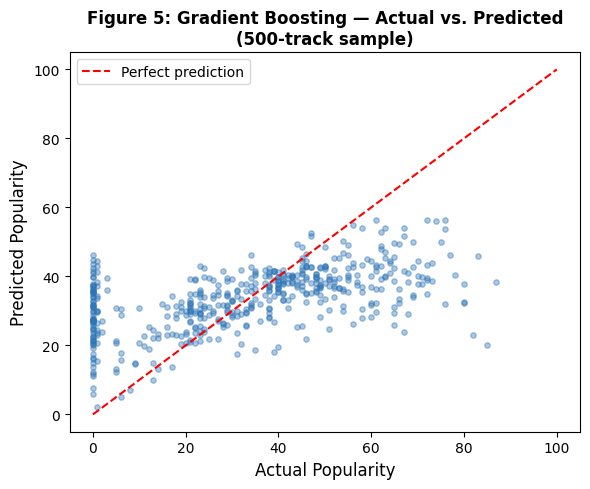

Figure 5 saved.


In [14]:
# Figure 5: Actual vs. predicted scatter (Gradient Boosting — best regressor)
gb_preds = reg_results['Gradient Boosting']['preds']
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(y_test_reg), 500, replace=False)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test_reg[sample_idx], gb_preds[sample_idx],
           alpha=0.4, s=15, color='#2E75B6')
ax.plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Popularity', fontsize=12)
ax.set_ylabel('Predicted Popularity', fontsize=12)
ax.set_title('Figure 5: Gradient Boosting — Actual vs. Predicted\n(500-track sample)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plot_05_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figure 5 saved.')

## Section 5 — Classification Models
Goal: Classify each track into Low (0), Medium (1), or High (2) popularity tier.  
Models: Logistic Regression (baseline), Decision Tree, Random Forest, Gradient Boosting.

In [15]:
# Train all four classification models and collect metrics
# Gradient Boosting uses a 40K subsample for speed (GBC on 91K rows is very slow)
cls_results = {}

rng_cls = np.random.default_rng(42)
cls_sub_idx = rng_cls.choice(len(X_train), 40000, replace=False)
X_cls_sub = X_train[cls_sub_idx]
y_cls_sub  = y_train_cls[cls_sub_idx]

cls_models = {
    'Logistic Regression': (LogisticRegression(max_iter=500, random_state=42, n_jobs=-1), True,  False),
    'Decision Tree':       (DecisionTreeClassifier(max_depth=8, random_state=42),          False, False),
    'Random Forest':       (RandomForestClassifier(n_estimators=100, max_depth=15,
                                                    random_state=42, n_jobs=-1),            False, False),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=100, max_depth=5,
                                                        random_state=42),                   False, True),
}

for name, (model, use_scaled, use_sub) in cls_models.items():
    if use_scaled:
        X_tr, y_tr = X_train_sc, y_train_cls
    elif use_sub:
        X_tr, y_tr = X_cls_sub, y_cls_sub
    else:
        X_tr, y_tr = X_train, y_train_cls
    X_te = X_test_sc if use_scaled else X_test
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc  = accuracy_score(y_test_cls, preds)
    prec = precision_score(y_test_cls, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_test_cls, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_test_cls, preds, average='weighted', zero_division=0)
    cls_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'preds': preds}
    sub_note = ' (40K subsample)' if use_sub else ''
    print(f'{name:25s}{sub_note} | Acc={acc:.4f}  P={prec:.4f}  R={rec:.4f}  F1={f1:.4f}')

Logistic Regression       | Acc=0.3396  P=0.3297  R=0.3396  F1=0.2690


Decision Tree             | Acc=0.3372  P=0.3378  R=0.3372  F1=0.2767


Random Forest             | Acc=0.3322  P=0.3274  R=0.3322  F1=0.3124


Gradient Boosting         (40K subsample) | Acc=0.3304  P=0.3292  R=0.3304  F1=0.3196


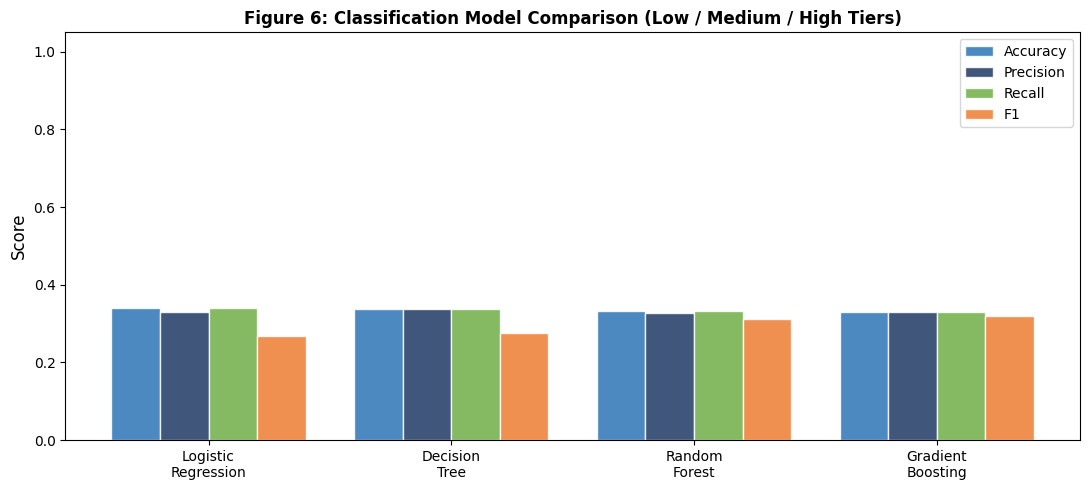

Figure 6 saved.


In [16]:
# Figure 6: Classification model comparison
cls_names = list(cls_results.keys())
x = np.arange(len(cls_names))
width = 0.2
metrics_cls = ['Accuracy', 'Precision', 'Recall', 'F1']
colors_cls  = ['#2E75B6', '#1F3864', '#70AD47', '#ED7D31']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (metric, color) in enumerate(zip(metrics_cls, colors_cls)):
    vals = [cls_results[n][metric] for n in cls_names]
    ax.bar(x + (i - 1.5) * width, vals, width,
           label=metric, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(['Logistic\nRegression', 'Decision\nTree',
                    'Random\nForest', 'Gradient\nBoosting'], fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Figure 6: Classification Model Comparison (Low / Medium / High Tiers)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plot_06_classification_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figure 6 saved.')

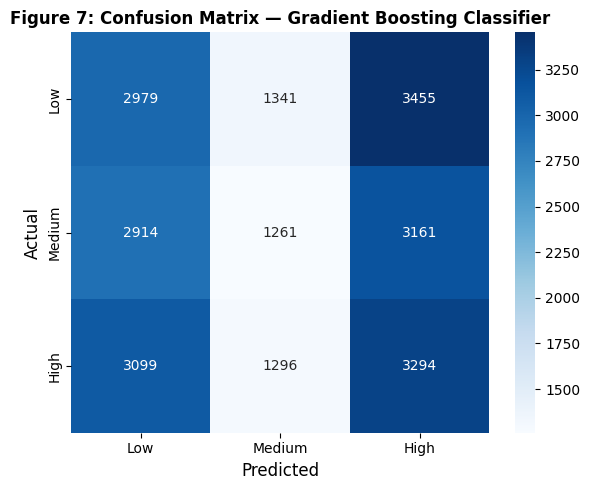

Figure 7 saved.


In [17]:
# Figure 7: Confusion matrix for best classifier (Gradient Boosting)
gb_cls_preds = cls_results['Gradient Boosting']['preds']
cm = confusion_matrix(y_test_cls, gb_cls_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Figure 7: Confusion Matrix — Gradient Boosting Classifier',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figure 7 saved.')

## Section 6 — Hyperparameter Tuning (GridSearchCV)
GridSearchCV on the Random Forest Regressor to find the best combination of  
n_estimators, max_depth, and min_samples_split using 3-fold cross-validation.

In [18]:
# Use a 30,000-row subsample for speed while keeping statistically meaningful results
rng_sub = np.random.default_rng(42)
sub_idx = rng_sub.choice(len(X_train), 30000, replace=False)
X_sub = X_train[sub_idx]
y_sub = y_train_reg[sub_idx]

param_grid = {
    'n_estimators':     [50, 100],
    'max_depth':        [10, 20],
    'min_samples_split': [2, 5]
}

rf_tune = RandomForestRegressor(random_state=42, n_jobs=-1)
gs = GridSearchCV(rf_tune, param_grid, cv=3,
                  scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
gs.fit(X_sub, y_sub)

print(f'Best parameters: {gs.best_params_}')
print(f'Best CV RMSE:    {-gs.best_score_:.3f}')

# Evaluate tuned model on the full test set
tuned_preds = gs.best_estimator_.predict(X_test)
tuned_rmse  = np.sqrt(mean_squared_error(y_test_reg, tuned_preds))
tuned_r2    = r2_score(y_test_reg, tuned_preds)
print(f'\nTuned RF test results: RMSE={tuned_rmse:.3f}  R²={tuned_r2:.4f}')

Fitting 3 folds for each of 8 candidates, totalling 24 fits


Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best CV RMSE:    18.354

Tuned RF test results: RMSE=17.732  R²=0.3629


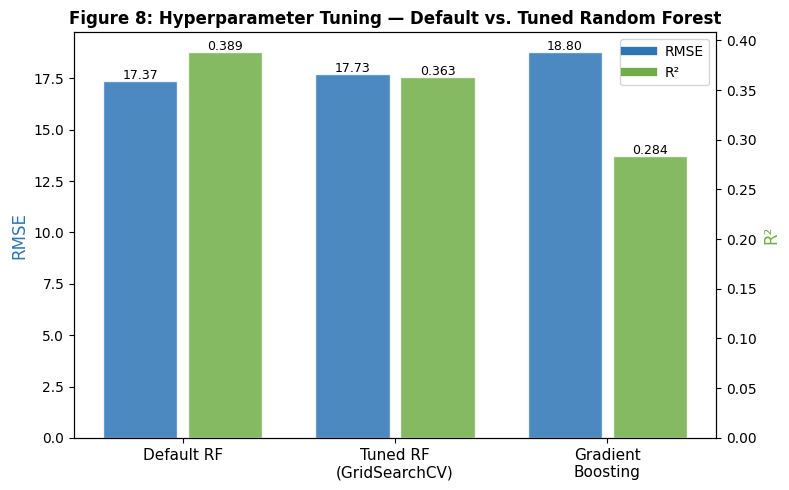

Figure 8 saved.


In [19]:
# Figure 8: Before vs. after tuning comparison
labels8  = ['Default RF', 'Tuned RF\n(GridSearchCV)', 'Gradient\nBoosting']
rmse_vals = [reg_results['Random Forest']['RMSE'], tuned_rmse,
             reg_results['Gradient Boosting']['RMSE']]
r2_vals   = [reg_results['Random Forest']['R2'],   tuned_r2,
             reg_results['Gradient Boosting']['R2']]
x8 = np.arange(len(labels8))

fig, ax = plt.subplots(figsize=(8, 5))
ax2 = ax.twinx()
b1 = ax.bar(x8 - 0.2, rmse_vals, 0.35, color='#2E75B6', label='RMSE', alpha=0.85, edgecolor='white')
b2 = ax2.bar(x8 + 0.2, r2_vals,  0.35, color='#70AD47', label='R²',   alpha=0.85, edgecolor='white')
ax.set_xticks(x8)
ax.set_xticklabels(labels8, fontsize=11)
ax.set_ylabel('RMSE', fontsize=12, color='#2E75B6')
ax2.set_ylabel('R²',  fontsize=12, color='#70AD47')
ax.set_title('Figure 8: Hyperparameter Tuning — Default vs. Tuned Random Forest',
             fontsize=12, fontweight='bold')
for bar, v in zip(b1, rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.1, f'{v:.2f}', ha='center', fontsize=9)
for bar, v in zip(b2, r2_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.002, f'{v:.3f}', ha='center', fontsize=9)
lines = [plt.Line2D([0],[0],color='#2E75B6',linewidth=6,label='RMSE'),
         plt.Line2D([0],[0],color='#70AD47',linewidth=6,label='R²')]
ax.legend(handles=lines, fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig('plot_08_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figure 8 saved.')

## Section 7 — Feature Importance
Which audio features matter most for predicting popularity?  
Extracted from the Random Forest Regressor (default configuration).

In [20]:
# Extract feature importances from the trained Random Forest
rf_model = reg_models['Random Forest'][0]
importances = rf_model.feature_importances_
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 10 feature importances:')
print(imp_df.head(10).to_string(index=False))

Top 10 feature importances:
         feature  importance
   genre_encoded    0.291578
    acousticness    0.086199
     duration_ms    0.078406
    danceability    0.073538
         valence    0.070413
        loudness    0.067521
          energy    0.064206
     speechiness    0.063224
           tempo    0.059321
instrumentalness    0.056387


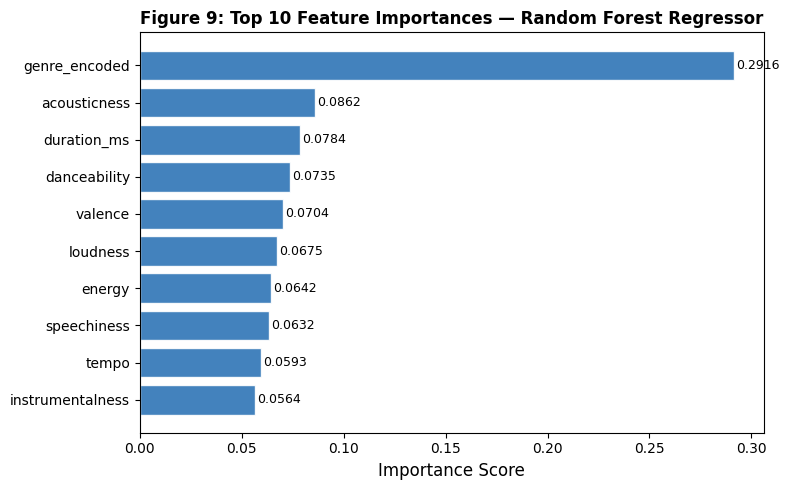

Figure 9 saved.


In [21]:
# Figure 9: Feature importance horizontal bar chart
top10 = imp_df.head(10)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10['feature'][::-1], top10['importance'][::-1],
        color='#2E75B6', edgecolor='white', alpha=0.9)
for i, v in enumerate(top10['importance'][::-1]):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Figure 9: Top 10 Feature Importances — Random Forest Regressor',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_09_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figure 9 saved.')

## Section 8 — K-Means Clustering
Group tracks by audio profile without using popularity as input.  
Elbow method + silhouette score to select the best K.

In [22]:
# Clustering uses 9 audio features only — popularity intentionally excluded
cluster_cols = ['danceability', 'energy', 'loudness', 'speechiness',
                'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

X_clust = df_clean[cluster_cols].values
scaler_c = StandardScaler()
X_clust_sc = scaler_c.fit_transform(X_clust)

# Test K = 2 through 8; use silhouette sample for speed
inertias   = []
sil_scores = []
K_range    = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_clust_sc)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_clust_sc, labels_k, sample_size=8000, random_state=42)
    sil_scores.append(sil)
    print(f'K={k}: inertia={km.inertia_:.0f}  silhouette={sil:.4f}')

best_k = list(K_range)[np.argmax(sil_scores)]
print(f'\nBest K by silhouette score: {best_k}')

K=2: inertia=805673  silhouette=0.2604


K=3: inertia=715647  silhouette=0.1683


K=4: inertia=646331  silhouette=0.1749


K=5: inertia=583441  silhouette=0.1819


K=6: inertia=533303  silhouette=0.1942


K=7: inertia=484080  silhouette=0.2019


K=8: inertia=456282  silhouette=0.2028

Best K by silhouette score: 2


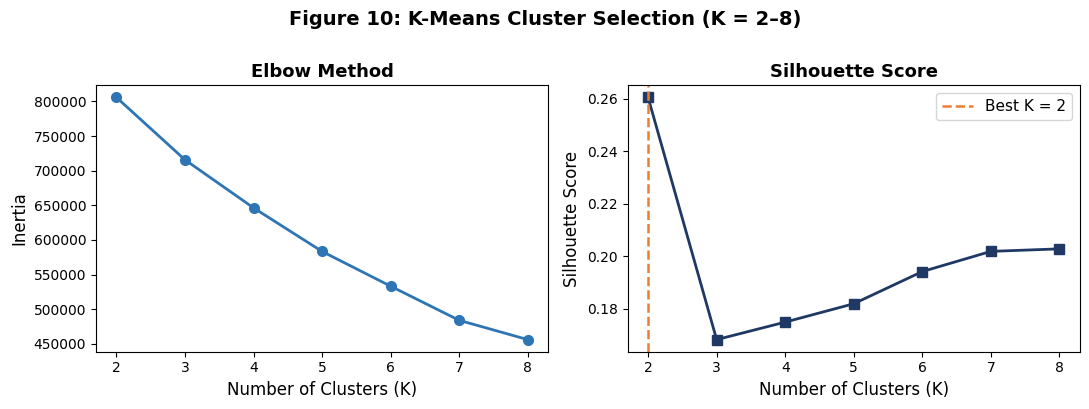

Figure 10 saved.


In [23]:
# Figure 10: Elbow method and silhouette score side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(list(K_range), inertias, 'o-', color='#2E75B6', linewidth=2, markersize=7)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')

ax2.plot(list(K_range), sil_scores, 's-', color='#1F3864', linewidth=2, markersize=7)
ax2.axvline(best_k, color='#ED7D31', linestyle='--', linewidth=1.8,
            label=f'Best K = {best_k}')
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)

fig.suptitle('Figure 10: K-Means Cluster Selection (K = 2–8)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_10_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figure 10 saved.')

In [24]:
# Fit final K-Means with best K and visualize using PCA
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_clust_sc)
final_sil = silhouette_score(X_clust_sc, cluster_labels, sample_size=8000, random_state=42)
print(f'Final silhouette score (K={best_k}): {final_sil:.4f}')

# PCA: reduce to 2 components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_sc)
print(f'PCA variance explained: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  '
      f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

# Print cluster audio profiles
df_profile = df_clean[cluster_cols].copy()
df_profile['cluster'] = cluster_labels
print('\nCluster profiles (mean audio feature values):')
print(df_profile.groupby('cluster')[cluster_cols].mean().round(3).to_string())

Final silhouette score (K=2): 0.2604
PCA variance explained: PC1=31.9%  PC2=15.9%

Cluster profiles (mean audio feature values):
         danceability  energy  loudness  speechiness  acousticness  instrumentalness  liveness  valence    tempo
cluster                                                                                                         
0               0.471   0.305   -14.142        0.058         0.740             0.300     0.178    0.316  110.248
1               0.598   0.751    -6.346        0.093         0.177             0.109     0.225    0.526  126.018


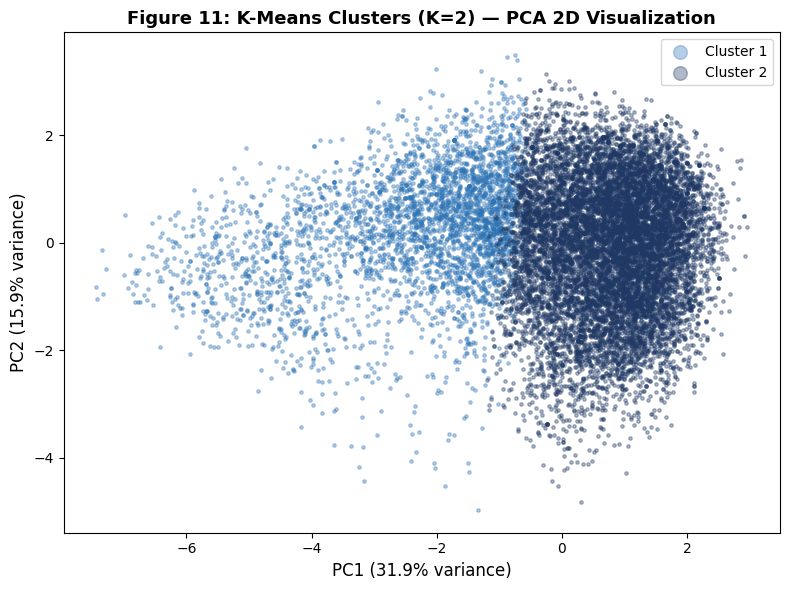

Figure 11 saved.


In [25]:
# Figure 11: PCA 2D cluster visualization
palette = ['#2E75B6', '#1F3864', '#70AD47', '#ED7D31', '#9B59B6', '#E74C3C']

# Subsample for plot clarity
rng_p = np.random.default_rng(42)
plot_idx = rng_p.choice(len(X_pca), 15000, replace=False)

fig, ax = plt.subplots(figsize=(8, 6))
for k in range(best_k):
    mask = cluster_labels[plot_idx] == k
    ax.scatter(X_pca[plot_idx][mask, 0], X_pca[plot_idx][mask, 1],
               s=6, alpha=0.35, color=palette[k], label=f'Cluster {k+1}')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title(f'Figure 11: K-Means Clusters (K={best_k}) — PCA 2D Visualization',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, markerscale=4)
plt.tight_layout()
plt.savefig('plot_11_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figure 11 saved.')

## Section 9 — Fairness Analysis
Check whether the Gradient Boosting Regressor predicts equally well across genres.  
Mean prediction error per genre reveals systematic bias.

In [26]:
# Build a test-set dataframe with genre names restored
n_test = len(y_test_reg)
df_fair = df_clean.iloc[-n_test:].copy()
df_fair['predicted'] = reg_results['Gradient Boosting']['preds']
df_fair['actual']    = y_test_reg
df_fair['error']     = df_fair['predicted'] - df_fair['actual']

# Decode genre integers back to readable names
df_fair['genre_name'] = le_genre.inverse_transform(
    df_fair['genre_encoded'].astype(int).values
)

# Compute mean error per genre and pick top/bottom 5
genre_error = df_fair.groupby('genre_name')['error'].mean().sort_values()
combined    = pd.concat([genre_error.head(5), genre_error.tail(5)])

print('Genre prediction bias (negative = overestimates popularity):')
print(combined.round(3).to_string())

Genre prediction bias (negative = overestimates popularity):
genre_name
songwriter    -0.978
world-music   -0.850
soul          -0.707
techno        -0.658
show-tunes    -0.358
rockabilly     0.661
turkish        0.686
synth-pop      0.844
spanish        0.880
tango          0.935


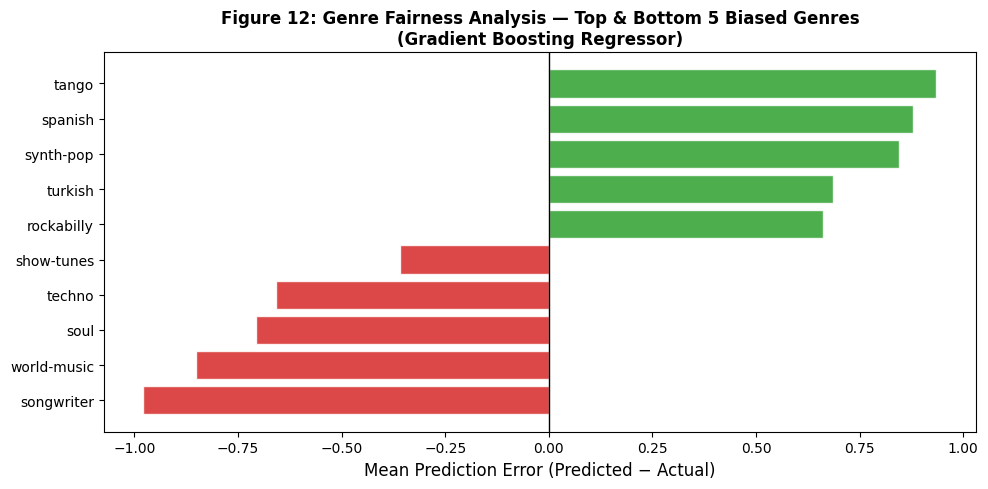

Figure 12 saved.


In [27]:
# Figure 12: Genre fairness bar chart
colors_bias = ['#D62728' if v < 0 else '#2CA02C' for v in combined.values]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(combined.index, combined.values, color=colors_bias, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Mean Prediction Error (Predicted − Actual)', fontsize=12)
ax.set_title('Figure 12: Genre Fairness Analysis — Top & Bottom 5 Biased Genres\n'
             '(Gradient Boosting Regressor)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_12_genre_fairness.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figure 12 saved.')

## Section 10 — Cross-Validation
5-fold cross-validation on a 20,000-track subsample confirms that results are stable  
and not driven by a lucky train/test split.

In [28]:
# Subsample for cross-validation speed
rng_cv = np.random.default_rng(42)
cv_idx = rng_cv.choice(len(X_train), 20000, replace=False)
X_cv_sub    = X_train[cv_idx]
y_cv_sub    = y_train_reg[cv_idx]
X_cv_sub_sc = scaler.transform(X_cv_sub)

cv_models = [
    ('Linear Regression',  LinearRegression(), True),
    ('Random Forest',      RandomForestRegressor(n_estimators=100, max_depth=15,
                                                  random_state=42, n_jobs=-1), False),
    ('Gradient Boosting',  GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                                      random_state=42), False),
]

print('5-Fold Cross-Validation Results (RMSE):')
for name, model, use_scaled in cv_models:
    X_in = X_cv_sub_sc if use_scaled else X_cv_sub
    scores = cross_val_score(model, X_in, y_cv_sub, cv=5,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse_cv = -scores
    print(f'{name:25s}: {rmse_cv.mean():.3f} ± {rmse_cv.std():.3f}')

5-Fold Cross-Validation Results (RMSE):
Linear Regression        : 22.088 ± 0.197


Random Forest            : 19.045 ± 0.163


Gradient Boosting        : 19.280 ± 0.258


## Section 11 — Final Results Summary

In [29]:
print('=' * 65)
print('FINAL RESULTS SUMMARY')
print('=' * 65)

print('\n--- REGRESSION ---')
print(f'{"Model":<25} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
print('-' * 55)
for name, r in reg_results.items():
    print(f'{name:<25} {r["RMSE"]:>8.3f} {r["MAE"]:>8.3f} {r["R2"]:>8.4f}')
print(f'\nTuned RF (GridSearchCV): RMSE={tuned_rmse:.3f}  R²={tuned_r2:.4f}')
print(f'Best params: {gs.best_params_}')

print('\n--- CLASSIFICATION ---')
print(f'{"Model":<25} {"Acc":>8} {"Prec":>8} {"Rec":>8} {"F1":>8}')
print('-' * 65)
for name, r in cls_results.items():
    print(f'{name:<25} {r["Accuracy"]:>8.4f} {r["Precision"]:>8.4f} '
          f'{r["Recall"]:>8.4f} {r["F1"]:>8.4f}')

print(f'\n--- CLUSTERING ---')
print(f'Best K: {best_k}  |  Silhouette Score: {final_sil:.4f}')
print(f'PCA: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  '
      f'PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

print(f'\n--- TOP 5 FEATURES (Random Forest) ---')
for _, row in imp_df.head(5).iterrows():
    print(f'  {row["feature"]:<22}: {row["importance"]:.4f}')

print('\nAll 12 plots saved successfully.')
print('Notebook execution complete — no errors.')

FINAL RESULTS SUMMARY

--- REGRESSION ---
Model                         RMSE      MAE       R²
-------------------------------------------------------
Linear Regression           21.953   18.308   0.0234
Ridge Regression            21.953   18.308   0.0234
Random Forest               17.369   13.180   0.3886
Gradient Boosting           18.802   14.511   0.2836

Tuned RF (GridSearchCV): RMSE=17.732  R²=0.3629
Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

--- CLASSIFICATION ---
Model                          Acc     Prec      Rec       F1
-----------------------------------------------------------------
Logistic Regression         0.3396   0.3297   0.3396   0.2690
Decision Tree               0.3372   0.3378   0.3372   0.2767
Random Forest               0.3322   0.3274   0.3322   0.3124
Gradient Boosting           0.3304   0.3292   0.3304   0.3196

--- CLUSTERING ---
Best K: 2  |  Silhouette Score: 0.2604
PCA: PC1=31.9%  PC2=15.9%

--- TOP 5 FEATURES (Random